In [ ]:
from functools import partial

from memory_profiler import memory_usage
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import numexpr as ne

# Understanding and Controlling Memory Usage in Numpy

In experimental neuroscience, we often work with large datasets: voltage traces, calcium imaging stacks, spike rasters, behavioral tracking coordinates, or multi-subject recordings collected over long sessions. It is easy for our analyses to become slow or crash—not because our algorithms are wrong, but because we underestimate memory usage.

In this session, we explore how Numpy uses memory. We calculate how much space our data really takes, examine how arrays are created, and investigate when memory is copied, reused, or temporarily expanded. Our goal is practical: we want to design analysis pipelines that are robust, scalable, and predictable when data becomes large, answering questions like:

  1. How large are our arrays, really?
  2. How does Numpy allocate memory when creating arrays?
  3. When do operations create views, and when do they create copies?
  4. How can we reduce peak memory usage in real pipelines?

Memory management is not premature optimization—it is experimental design at the computational level. By measuring and reasoning carefully, we can build pipelines that remain stable as our datasets grow from megabytes to gigabytes and beyond.

In real experimental workflows, this difference determines whether an analysis runs overnight—or crashes halfway through!

## Setup

### Utility Functions

Please run the code below, to load the utility functions (we'll mainly use `utils.analyze_memory()`), that we'll use in this session:

In [ ]:
import sys
import time
from contextlib import contextmanager


def _format_duration(seconds: float, precision: int = 1) -> str:
    """
    Takes a time in seconds and returns a string (e.g. ) that is more human-readable.

    Looking to do this in a real project?  Some alternatives:
      - `humanize`: https://humanize.readthedocs.io/en/latest/
    """


    if seconds < 0:
        raise ValueError("Duration must be non-negative")

    units = [("s", 1), ("ms", 1e-3), ("µs", 1e-6)]

    for unit, scale in units:
        if seconds >= scale:
            value = seconds / scale
            return f"{value:.{precision}f} {unit}"
    else:
        return f"{seconds / 1e-9:.{precision}f} ns"
    

@contextmanager
def _trace_lines_of(fun):
    "a (very) basic line tracer.  Collects (timestamp, lineno) for each executed line inside a function."
    try:
        target_code = fun.__code__
    except AttributeError:
        yield []
        return
    target_frame = None
    records = []

    def tracer(frame, event, arg):
        nonlocal target_frame

        if event == "call" and frame.f_code is target_code:
            target_frame = frame
            return tracer

        elif frame is target_frame:
            if event == "line":
                records.append((frame.f_lineno, time.perf_counter()))
            elif event == "return":
                target_frame = None

            return tracer

    old_trace = sys.gettrace()
    sys.settrace(tracer)

    try:
        yield records
    finally:
        sys.settrace(old_trace)


def _sample_memory(fun, interval=.00005):
    
    # Collect memory traces and line number timings
    with _trace_lines_of(fun) as line_trace:
        memory_trace = memory_usage(fun, interval=interval, timestamps=True)

    # Make Comparable DataFrames out of the two datasets
    line_trace_df = pd.DataFrame(line_trace, columns=['Line', 'Time'])
    if len(line_trace_df) > 0:
        line_trace_df.Time -= line_trace_df.Time[0]
    
    memory_trace = memory_trace[1:]
    
    memory_trace_df = pd.DataFrame(memory_trace, columns=['Memory', 'Time'])
    memory_trace_df['Time'] -= memory_trace_df['Time'][0]
    memory_trace_df['Memory'] -= memory_trace_df['Memory'][0]

    return line_trace_df, memory_trace_df


def _plot_memory(data: pd.DataFrame, x='Time', y='Memory', ax=None):
    "Makes a line plot."

    peak_memory_mb = round(data[y].max(), 1)
    total_time = _format_duration(data[x].max())

    ax = ax if ax is not None else plt.gca()
    ax.plot(data[x], data[y])
    ax.fill_between(data[x], data[y], 0, alpha=0.3)
    ax.set(xlabel='Time (s)', ylabel='Memory (MB)', title=f"Total Time: {total_time} -- Peak Memory: {peak_memory_mb} MB")

    ax.margins(y=0)
    
    ylim_max = data[y].max() * 1.05 if data[y].max() > 1 else 1
    ax.set_ylim(0, ylim_max)
    
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    return ax


def _plot_line_numbers(data: pd.DataFrame, x='Time', text='Line', linestyle='--', color='gray', alpha=0.3, fontsize=6, ax=None):
    "Makes vertical lines with text above them."
    
    ax = ax if ax is not None else plt.gca()
    ymin, ymax = ax.get_ylim()
    y_text = ymax - 0.04 * (ymax - ymin)

    for _, row in data.iterrows():
        ax.axvline(row[x], linestyle=linestyle, alpha=alpha, color=color)
        ax.text(row[x], y_text, str(int(row[text])), rotation=90, ha="right", va="bottom", fontsize=fontsize)
        
    return ax

def _analyze_memory(*funs, interval=.00005, linestyle='--', color='gray', alpha=0.3, fontsize=6):
    "Convenient wrapper function: records memory traces of provided functions and makes the plot"

    if len(funs) == 1:
        fig, axes = plt.subplots();
        axes = [axes]
    else:
        fig, axes = plt.subplots(nrows=len(funs), sharex=True)


    print(axes)
    for ax, fun in zip(axes, funs):
        lines, memory = _sample_memory(fun, interval=interval)
        # ax = ax if ax is not None else plt.gca()
        _plot_memory(memory, ax=ax)
        _plot_line_numbers(lines, linestyle=linestyle, color=color, alpha=alpha, fontsize=fontsize, ax=ax)
    
    y_max = max([ax.get_ylim()[1] for ax in axes])
    for ax in axes:
        ax.set_ylim(0, y_max)

    plt.tight_layout()


class utils:
    sample_memory = _sample_memory
    plot_memory = _plot_memory
    plot_line_numbers = _plot_line_numbers
    analyze_memory = _analyze_memory

---

## Measuring the True Size of Our Data

Before optimizing code, we need to understand scale. Every dataset we collect has a concrete memory cost determined by:

  - Number of elements
  - Data type (dtype)
  - Array shape

We often think in terms of subjects, sessions, and minutes of recording—but our computers think in bytes.

For example: if we record calcium imaging at 24 frames per second for 30 minutes at 512×512 resolution, the dataset quickly reaches many gigabytes—even before preprocessing.

In this section, we calculate memory requirements directly from array shape and dtype. We move from intuition (“this seems big”) to exact numbers.


### Reference

| Code                         | Description                                          |
| ---------------------------- | ---------------------------------------------------- |
| `array.nbytes`               | Total number of bytes used by the array data buffer. |
| `array.dtype`                | Shows the data type (e.g., `float64`, `int16`).      |
| `array.itemsize`             | Number of bytes per single element.                  |
| `array.shape`                | Dimensions of the array.                             |
| `np.empty(shape, dtype=...)` | Allocates memory without initializing values.        |
| `np.zeros(shape, dtype=...)` | Allocates memory and fills with zeros.               |
| `np.ones(shape, dtype=...)`  | Allocates memory and fills with ones.                |
| `1024**2`, `1024**3`         | Convert bytes to MB or GB.                           |
| `1 byte = 8 bits`            | Needed when converting bit calculations to bytes.    |


### Exercises

**Example**: You record 1,000,000 voltage levels from an implanted electrode, and store the data as a 64-bit float array. How Many Bytes do these 1,000,000 64-bit floats take up in memory?

In [ ]:
np.empty(1_000_000, dtype=np.float64).nbytes

8000000

**Exercise**: How many bytes would the data take up, it were instead stored as  32-bit floats?

**Exercise**: Integers are a lot simpler than floats; they are just counting numbers.  Perhaps we should store our recording as integers.  What takes up more memory: a million 32-bit integers, or a million 32-bit floats?

**Exercise**: I have recorded a calcium image stack as a 3D array: 1000 time points x 256 pixels tall x 256 pixels wide.  To keep the data range high, I want to store the data as "uint16"s -- unsigned, 16-bit integers.

How big will the array be:
  1. In Bytes?
  2. In Kilobytes? (1 KB = 1024 B)
  3. In Megabytes? (1 MB = 1024 KB)
  4. In Gigabytes? (1 GB = 1024 GM)


**Exercise**: I have just bought a new camera that has even better resolution-- each image is now 512 pixels tall x 512 pixels wide!  If I use this camera instead of my old 256x256 camera, How many times bigger will my datasets be?


**Exercise**: Okay, now I want acquire a lot of data--way more than will fit on my machine.  Here are the specifications; how much memory should I expect it to take up, in total?
  - **14** subjects, of
  - **10** sessions, of
  - **30** minutes, of
  - **24** frames per second, of
  - **512 x 512** images, stored as
  - **16**-bit, unsigned integer arrays.

*Note*: You'll get an "Out of Memory" error if you try to create this directly--better to calculate it by hand!

*Note*: A byte is 8 bits.

## Creating Arrays: How Numpy Allocates Memory

Creating arrays is not neutral. Different functions allocate and initialize memory in different ways. Some operations:

  - Reserve memory without writing values (np.empty)
  - Allocate and initialize values (np.ones, np.zeros)
  - Generate computed sequences (np.arange)
  - Fill with random values (np.random.random)

These differences affect execution time and peak memory usage. For example: when we preallocate a large array for storing spike counts across 500 trials, choosing np.empty() versus np.zeros() may noticeably change runtime and memory pressure.

In this section, we examine how array creation methods differ, and how those differences scale as array size increases.

| Code                         | Description                                                |
| ---------------------------- | ---------------------------------------------------------- |
| `partial(function, args...)` | Prepares a function with fixed arguments for benchmarking. |
| `utils.analyze_memory(fun)`  | Records memory usage and runtime of a function.            |
| --- | ---  |
| `np.ones(n)`                 | Allocates and fills array with ones.                       |
| `np.zeros(n)`                | Allocates and fills array with zeros.                      |
| `np.empty(n)`                | Allocates memory without writing values.                   |
| `np.arange(n)`               | Creates array with sequential values.                      |
| `np.random.random(n)`        | Allocates array filled with random floats.                 |
| --- | --- |
| `time.sleep(seconds)`        | Adds delay to visually separate memory events in plots.    |


### Exercises

**Example**: Using `np.ones()`: How long does it take numpy to create a million float64s?

[<Axes: >]


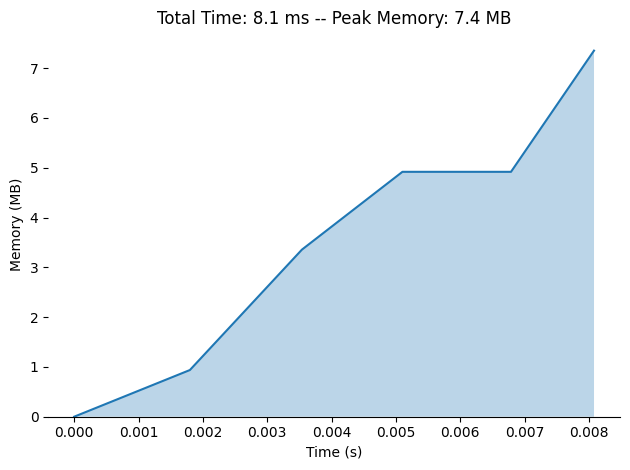

In [ ]:
utils.analyze_memory(
    partial(np.ones, 1_000_000, dtype=np.float64)
)

**Exercise**: Using `np.ones()`: How long does it take numpy to create 4 million float64s?

**Exercise**: Examine the memory traces of both the creation of 1-million and the creation of 2-million values (`utils.analyze_memory(partial(fun1), partial(fun2))`); Are both arrays working at the same speed?

**Exercise**: White takes more time to create: an array all filled with 1 (`np.ones()`), or an array filled with counting numbers (`np.arange()`)?  Is there a difference in total memory usage?

**Exercise**: Is there a difference in performance between creating an array all filled with 1 (`np.ones()`), and creating an array all filled with 0 (`np.zeros()`)?

**Exercise**: Is there a difference in performance between creating an array all filled with 0 (`np.zeros()`), and eplicitly telling Numpy not to write any data into an array (`np.empty()`)?

**Exercise**: Is there a difference in performance between creating an array all filled with 1 (`np.ones()`), and filling the array with random values (`np.random.random()`)?


## Views vs Copies: When Is New Memory Allocated?

One of the most important concepts in Numpy is the difference between a view and a copy. This distinction determines whether our pipeline silently doubles memory usage:

  - A **view** shares memory with the original array.
  - A **copy** allocates new memory.


For example: when we extract a subset of neurons from a large calcium imaging matrix using slicing, we may only create a view. But if we call .copy() or wrap with np.array(), we allocate new memory—possibly gigabytes.

In this section, we trace memory line-by-line inside small pipeline functions. We observe:

  - When slicing creates views
  - When copying duplicates memory
  - When del actually releases memory
  - Why memory sometimes appears not to shrink

This helps us understand why a long preprocessing pipeline may suddenly exceed RAM limits.

### Exercises

Now we'll create multi-stage data pipelines, putting each step in a function, and looking at how each line affects memory usage.  

**Tip**: To see the connection between the line numbers plotted in `utils.analyze_memory()` and your code, you can view the line numbers in your code by right-clicking next to the code cell and clicking the  "Show Cell Line Numbers" option in the context menu.

**Example**: Create a function that makes two identical arrays using `np.random.random()`. Does the total space take up the same amount as a single two-column array?

[<Axes: >]


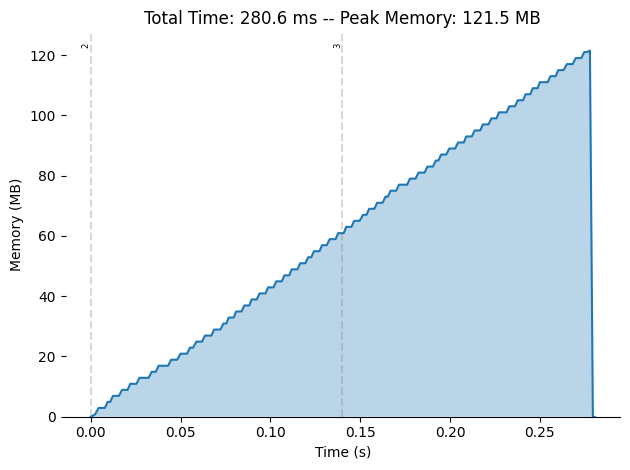

In [ ]:
def main():
    data = np.random.random(8_000_000)
    data2 = np.random.random(8_000_000)
    
utils.analyze_memory(main)

**Exercise**: Create a function that makes an array using `data = np.random.random()`, the deletes the array using `del data`. Does this affect the total memory used?

**Exercise**: Create a function that:
  1. makes an array using `data = np.random.random()`, 
  2. then creates a second array object by slicing the first (i.e. `data2 = data[:]`), 
  3. then creates another data array by calling `data3 = data.copy()`, 
  4. then creates another data array by calling `data4 = np.array(data), 

Are there any differences in performance between these methods?

*Tip*: if it's hard to seperate out the behavior of lines in the plot, putting (`time.sleep(0.002)`) between the lines can help.

**Exercise**: While `del` can release memory, it doesn't always work.  Let's create the scenario:
  1. makes an array using `data = np.random.random()`, 
  2. makes another array using `data2 = np.random.random()`, 
  3. make another array by slicing the second: `data3 = data2[:]`
  4. then delete the first array: `del data`
  5. then delete the second array: `del data2`
  6. then delete the third array: `del data3`

Are there any differences in performance between these methods?  When does memory get released?

*Tip*: if it's hard to seperate out the behavior of lines in the plot, putting (`time.sleep(0.002)`) between the lines can help.

## Controlling Temporary Arrays to Reduce Peak Memory


Many memory problems are not caused by stored data—but by temporary arrays created during computation.  Expressions like  `x = x * 2 * 3 * 4 + 1`  can generate multiple intermediate arrays before assigning the final result.

In large datasets, these temporary allocations can dramatically increase peak memory usage—even if the final result is small.

For example: when normalizing fluorescence signals across thousands of neurons and timepoints, a sequence of chained operations may briefly double or triple memory usage before returning to normal.

In this section, we compare:

  - In-place operations (x *= 2) vs reassignment (x = x * 2)
  - Combined expressions vs factored expressions
  - np.multiply(..., out=x) vs creating new arrays

We focus on reducing peak memory—not just total memory.To compare the operations, we'll a small function for each and then use `utils.analyze_memory()` to compare them as we did previously.

**Example**: For numpy arrays, is there a difference in memory performance between:
  1. `x = x * 2`
  2. `x *= 2`


[<Axes: > <Axes: >]


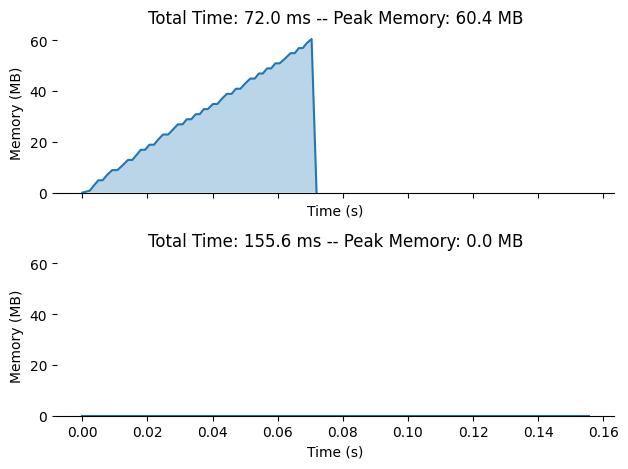

In [ ]:
def fun1(x):
    x = x * 2

def fun2(x):
    x *= 2

utils.analyze_memory(
    partial(fun1, np.ones(8_000_000)),
    partial(fun2, np.ones(8_000_000))
)


**Exercise**: For numpy arrays, is there a difference in memory performance between:
  1. `x = x * 2 * 3 * 4 + 1`
  2. `x = x * (2 * 3 * 4 + 1)`


**Exercise**: For numpy arrays, is there a difference in memory performance between:
  1. `x = np.multiply(x, 2)`
  2. `np.multiply(x, 2, out=x)`


**Exercise**: For numpy arrays, is there a difference in memory performance between:

1. `x = x[x > threshold]`
2. `mask = x > threshold; x[mask] = 0`

**Exercise**: For numpy arrays, is there a difference in memory performance between:

1. `x = x.astype(np.float32)`
2. `x = x.astype(np.float32, copy=False)`



**Exercise**: For numpy arrays, is there a difference in memory performance between:

1. Operating directly on a sliced array:
   `x = big_array[:, ::2]; x = x * 2`
2. Forcing a contiguous copy first:
   `x = big_array[:, ::2].copy(); x *= 2`


## Reducing Temporary Arrays with `numexpr`


In the previous section, we saw that chained arithmetic expressions can silently create multiple temporary arrays. Even simple expressions like:

```python
x = x * 2 + 3
```

may allocate intermediate results before assigning the final output.

For large datasets, this increases peak memory usage and slows computation.

`numexpr` provides an alternative way to evaluate array expressions. Instead of creating many temporary arrays, it:

  - Breaks expressions into small chunks
  - Evaluates them in blocks
  - Minimizes temporary memory
  - Uses multiple CPU cores automatically

For example: when normalizing fluorescence traces across millions of time points, `numexpr` can reduce peak memory while speeding up computation.

In this section, we compare standard NumPy expressions with `numexpr`, and we explore both one-off evaluation and reusable compiled expressions.

### Reference

| Code                                  | Description                             |
| ------------------------------------- | --------------------------------------- |
| `ne.evaluate("x * 2 + 3")`            | Evaluates an expression using numexpr.  |
| `ne.evaluate(expr, local_dict={...})` | Provides variables explicitly.          |
| `ne.set_num_threads(n)`               | Controls how many CPU threads are used. |
| `ne.NumExpr("x * 2 + 3")`             | Pre-compiles an expression for reuse.   |
| `compiled(x=x)`                       | Executes a precompiled expression.      |


### Exercises



**Example**: For numpy arrays, is there a difference in memory performance between:

1. `x = x * 2 + 3`
2. `x = ne.evaluate("x * 2 + 3")`

[<Axes: > <Axes: >]


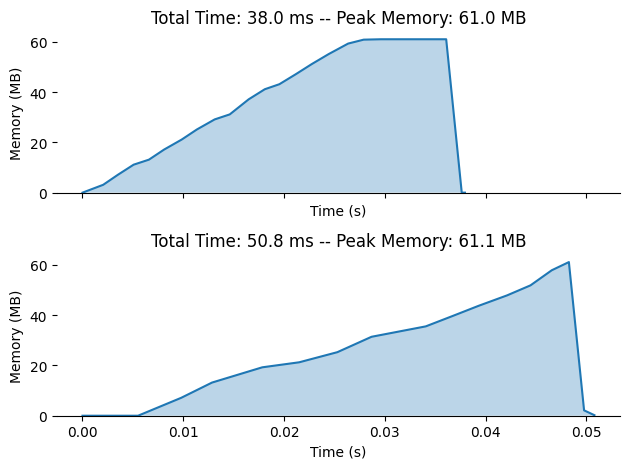

In [ ]:
def fun1(x):
    x * 2 + 3
    
def fun2(x):
    ne.evaluate("x * 2 + 3")

utils.analyze_memory(
    partial(fun1, np.ones(8_000_000)),
    partial(fun2, np.ones(8_000_000)),
);

**Exercise**: For numpy arrays, is there a difference in memory performance between:

1. `x = x * y + z`
2. `x = ne.evaluate("x * y + z")`


**Exercise**: For repeated computations, is there a difference in performance between:

1. Calling `ne.evaluate("x * 2 + 3")` inside a loop
2. Pre-compiling once, then using it again and again?:

   ```python
   f = ne.NumExpr("x * 2 + 3")
   for _ in range(n):
       x = f(x)
   ```
